# Challenge: Optimization on Other Datasets

## Download data from `yfinance`

In [95]:
import yfinance as yf

ticker = 'ZM'# Zoom
df = yf.download(ticker, multi_level_index=False, auto_adjust=False)
df

[*********************100%***********************]  1 of 1 completed


,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2026-04-30,97.150002,97.150002,97.800003,93.489998,95.500000,7949200
2026-05-01,103.440002,103.440002,104.139999,98.809998,99.000000,5825900
2026-05-04,106.629997,106.629997,107.910004,103.209999,103.550003,5501900
2026-05-05,109.099998,109.099998,109.500000,105.330002,107.014999,4238500
2026-05-06,105.129997,105.129997,108.260002,104.610001,106.744003,6186800
2026-05-07,108.360001,108.360001,108.919998,105.330002,107.650002,4750600
2026-05-08,109.209999,109.209999,109.410004,105.220001,108.250000,3771200
2026-05-11,107.120003,107.120003,111.559998,105.459999,109.305000,4110300
2026-05-12,102.959999,102.959999,106.654999,102.220001,106.360001,4890100


## Preprocess the data

### Filter the date range

- Since 1 year ago at least

In [96]:
df = df.loc['2025-01-01':].copy()
df

,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2026-04-30,97.150002,97.150002,97.800003,93.489998,95.500000,7949200
2026-05-01,103.440002,103.440002,104.139999,98.809998,99.000000,5825900
2026-05-04,106.629997,106.629997,107.910004,103.209999,103.550003,5501900
2026-05-05,109.099998,109.099998,109.500000,105.330002,107.014999,4238500
2026-05-06,105.129997,105.129997,108.260002,104.610001,106.744003,6186800
2026-05-07,108.360001,108.360001,108.919998,105.330002,107.650002,4750600
2026-05-08,109.209999,109.209999,109.410004,105.220001,108.250000,3771200
2026-05-11,107.120003,107.120003,111.559998,105.459999,109.305000,4110300
2026-05-12,102.959999,102.959999,106.654999,102.220001,106.360001,4890100


### Create the target variable

#### Percentage change

- Percentage change on `Adj Close` for tomorrow

In [97]:
df['change_tomorrow'] = df['Adj Close'].pct_change(-1)
df.change_tomorrow = df.change_tomorrow * -1
df.change_tomorrow = df.change_tomorrow * 100

#### Remove rows with any missing data

In [98]:
df = df.dropna().copy()
df

,Adj Close,Close,High,Low,Open,Volume,change_tomorrow
Date,,,,,,,
2026-04-30,97.150002,97.150002,97.800003,93.489998,95.500000,7949200,6.080821
2026-05-01,103.440002,103.440002,104.139999,98.809998,99.000000,5825900,2.991649
2026-05-04,106.629997,106.629997,107.910004,103.209999,103.550003,5501900,2.263979
2026-05-05,109.099998,109.099998,109.500000,105.330002,107.014999,4238500,-3.776278
2026-05-06,105.129997,105.129997,108.260002,104.610001,106.744003,6186800,2.980808
2026-05-07,108.360001,108.360001,108.919998,105.330002,107.650002,4750600,0.778316
2026-05-08,109.209999,109.209999,109.410004,105.220001,108.250000,3771200,-1.951079
2026-05-11,107.120003,107.120003,111.559998,105.459999,109.305000,4110300,-4.040408
2026-05-12,102.959999,102.959999,106.654999,102.220001,106.360001,4890100,-0.517425


## Compute Machine Learning model

Proposal: Random Forest within `ensemble` module of `sklearn` library

In [99]:
from sklearn.ensemble import RandomForestRegressor

In [100]:
model= RandomForestRegressor(max_depth=20,random_state=42)

In [101]:
y= df.change_tomorrow
X= df.drop(columns='change_tomorrow')

In [102]:
model.fit(X,y)

RandomForestRegressor(max_depth=20, random_state=42)

In [103]:
model.score(X,y)

0.8734705543089429

## Parametrize & optimize the investment strategy

### Create Strategy class

In [104]:
from backtesting import Strategy

In [105]:
class Regression(Strategy):
    limit_sell = -5
    limit_buy= 1

    def init(self):
      self.model = model
      self.already_bought= False

    def next(self):
      explanatory_today = pd.DataFrame([self.data.df.iloc[-1]])
      forecast_tomorrow = self.model.predict(explanatory_today)[0]

      if forecast_tomorrow > self.limit_buy and self.already_bought == False:
        self.buy()
        self.already_bought= True

      elif forecast_tomorrow < self.limit_sell and self.already_bought == True:
        self.sell()
        self.already_bought = False

      else:
          pass


### Create `Backtest` class

In [111]:
import pandas as pd
from backtesting import Backtest


In [112]:
bt = Backtest(
   X, Regression, cash=10000,
    commission=.002, exclusive_orders=True
)

### Optimize backtesting with multiple combinations

In [113]:
import multiprocessing as mp
mp.set_start_method('fork',force=True)

In [114]:
stats_skopt, heatmap, optimize_result = bt.optimize(
    limit_buy=[0, 10],
    limit_sell=[-10, 0],
    maximize='Return [%]',
    method='skopt',
    max_tries=500,
    random_state=0,
    return_heatmap=True,
    return_optimization=True)

/Users/neemaurassa/Library/Python/3.9/lib/python/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(2), np.int64(-2)] before, using random point [np.int64(0), np.int64(-9)]
  warnings.warn(


### Which are the best values for the parameters?

In [116]:
import numpy as np

In [117]:
dff = heatmap.reset_index()
dff = dff.pivot(index='limit_buy', columns='limit_sell', values='Return [%]')

dff.sort_index(axis=1, ascending=False)\
    .style.format(precision=0)\
    .background_gradient(vmin=np.nanmin(dff), vmax=np.nanmax(dff))\
    .highlight_null(props='background-color: transparent; color: transparent')

limit_sell,0,-1,-2,-3,-4,-5,-6,-7,-8,-9,-10
limit_buy,,,,,,,,,,,
0,nan,nan,nan,nan,nan,nan,nan,nan,nan,-4,nan
1,nan,nan,nan,nan,nan,-4,nan,-4,nan,nan,nan
2,nan,nan,3,nan,-7,nan,-7,nan,nan,nan,nan
3,nan,1,nan,-8,nan,nan,nan,nan,-8,nan,nan
4,nan,nan,1,-8,nan,nan,nan,nan,nan,nan,-8
5,1,1,nan,nan,nan,-8,nan,nan,nan,nan,nan
6,nan,nan,nan,nan,nan,nan,nan,nan,nan,-8,nan
7,0,nan,nan,nan,nan,nan,nan,0,nan,0,nan
8,nan,nan,nan,0,nan,0,0,nan,nan,nan,nan


### How to interpret smart optimization?

#### Number of evaluations

https://kernc.github.io/backtesting.py/doc/examples/Parameter%20Heatmap%20&%20Optimization.html

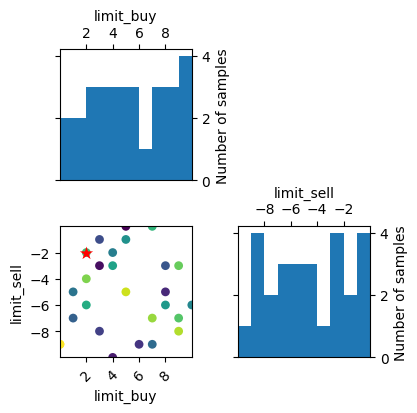

In [118]:
from skopt.plots import plot_evaluations

_ = plot_evaluations(optimize_result, bins=10)

#### Density

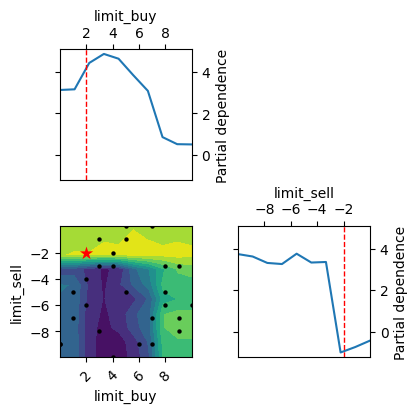

In [119]:
from skopt.plots import plot_objective

_ = plot_objective(optimize_result, n_points=10)

## How to solve the overfitting problem?

> Backtest the investment strategy on a validation set.

Next chapter → [The Overfitting Problem in Backtesting]()

![](<src/09_Table_The Overfitting.png>)